### MODULE 2: MATHEMATICS OF AI

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("../data/raw/Telco Customer Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [11]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
) 

df = df.dropna(subset=["TotalCharges"])
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Q1. Represent the dataset as a numerical matrix (use numerical features only) and determine its shape𝑋 and rank.


In [12]:
matrix_X = df[['tenure', 'MonthlyCharges', 'TotalCharges']].to_numpy()

In [13]:
print(f"Matrix X:\n{matrix_X}")
print(f"Shape of Matrix X: {matrix_X.shape}")
print(f"Dtype of Matrix X: {matrix_X.dtype}")
print(f"Rank of Matrix X: {np.linalg.matrix_rank(matrix_X)}")

Matrix X:
[[1.0000e+00 2.9850e+01 2.9850e+01]
 [3.4000e+01 5.6950e+01 1.8895e+03]
 [2.0000e+00 5.3850e+01 1.0815e+02]
 ...
 [1.1000e+01 2.9600e+01 3.4645e+02]
 [4.0000e+00 7.4400e+01 3.0660e+02]
 [6.6000e+01 1.0565e+02 6.8445e+03]]
Shape of Matrix X: (7032, 3)
Dtype of Matrix X: float64
Rank of Matrix X: 3


Q2. Encode the target variable Churn (Yes=1, No=0), then apply Linear Regression using tenure and MonthlyCharges to predict churn based on the model: 𝑦^ = 𝑋𝑤 + 𝑏

In [26]:
# Tạo một mảng nhị phân ngẫu nhiên để giả lập biến mục tiêu churn với giá trị chính là (0: No, 1: Yes)
y = (
    df["Churn"]
    .map({"No": 0, "Yes": 1})
    .to_numpy()
)
print(f"Target variable (y_churn):\n{y}")

feature = df[
    ['tenure', 'MonthlyCharges']
    
].to_numpy()

# Thêm cột y_churn vào ma trận X để tính bias b
X_bias = np.hstack((np.ones((feature.shape[0], 1)), feature[:, :2]))
w_opt = np.linalg.inv(X_bias.T @ X_bias) @ X_bias.T @ y
print(f"Optimal weights (w_opt):\n{w_opt}")
print(f"Intercept (b): {w_opt[0]}, Coefficients (w): {w_opt[1:]}")

Target variable (y_churn):
[0 0 1 ... 0 1 0]
Optimal weights (w_opt):
[ 0.23141206 -0.00769847  0.00438239]
Intercept (b): 0.2314120632274117, Coefficients (w): [-0.00769847  0.00438239]


In [18]:
y_pred = X_bias @ w_opt
print(f"Predicted values (y_pred):\n{y_pred}")

Predicted values (y_pred):
[0.35452792 0.21924125 0.45200679 ... 0.27644765 0.52666796 0.18631266]


Q3. Compute the probabilities and𝑃(𝐶ℎ𝑢𝑟𝑛 = 1) from the dataset.𝑃(𝐶ℎ𝑢𝑟𝑛 = 1∣𝐶𝑜𝑛𝑡𝑟𝑎𝑐𝑡 = 𝑀𝑜𝑛𝑡ℎ − 𝑡𝑜 − 𝑚𝑜𝑛𝑡ℎ)

In [27]:
pred_churn = np.mean(
    df["Churn"] == "Yes"
)

month_contract = (
    df["Contract"]
    == "Month-to-month"
)

p_conditional = np.mean(
    df.loc[
        month_contract,
        "Churn"
    ] == "Yes"
)

print("P(Churn=1):", pred_churn)

print(
    "P(Churn=1 | Contract=Month-to-month):",
    p_conditional
)

P(Churn=1): 0.26578498293515357
P(Churn=1 | Contract=Month-to-month): 0.4270967741935484


Q4. Given the Mean Squared Error loss, derive and compute the gradient with respect to for the dataset:𝑤
𝐿 = 1𝑛 ∑(𝑦 − 𝑦^)2

In [28]:
n = len(y)

gradient = (2 / n) * (feature.T @ (feature @ w_opt[1:] - y))

print(f"Gradient:\n{gradient}")

Gradient:
[-15.00558484 -29.9901741 ]


Q5. Compute the variance of MonthlyCharges and the covariance between MonthlyCharges and tenure.

In [29]:
monthly = df["MonthlyCharges"].to_numpy()

tenure = df["tenure"].to_numpy()

variance = np.var(monthly)

covariance = np.cov(monthly, tenure)[0, 1]

print("Variance:", variance)

print("Covariance:", covariance)

Variance: 905.0371035869182
Covariance: 182.29952560163844


Q7. Construct the covariance matrix using numerical features and compute its eigenvalues and
eigenvectors.

In [ ]:
cov_matrix = np.cov(matrix_X.T)
eigvals, eigvecs = np.linalg.eig(cov_matrix)

print("Eigenvalues")
print(eigvals)

print("\nEigenvectors")
print(eigvecs)

Eigenvalues
[5.13904705e+06 8.56756329e+01 6.27320645e+02]

Eigenvectors
[[-0.00894215 -0.89691499  0.44211259]
 [-0.00864116 -0.44204445 -0.89695152]
 [-0.99992268  0.01184105  0.00379756]]


Q7. Perform Singular Value Decomposition (SVD) on matrix (numerical features only) and interpret the meaning of U and in the context of the dataset:𝑈 Σ 𝑉𝑇 𝑋 = 𝑈Σ𝑉

In [35]:
U, S, VT = np.linalg.svd(matrix_X)

print("U shape:", U.shape)

print("S shape:", S.shape)

print("VT shape:", VT.shape)

U shape: (7032, 7032)
S shape: (3,)
VT shape: (3, 3)


Q8. Implement Gradient Descent to optimize the Linear Regression model parameters and visualize the loss convergence over iterations.

In [36]:
X_gd = np.c_[np.ones(len(feature)), feature]

w = np.zeros(X_gd.shape[1])

lr = 0.0001

epochs = 1000

losses = []

for _ in range(epochs):

    y_hat = X_gd @ w

    loss = np.mean((y - y_hat) ** 2)

    losses.append(loss)

    grad = (2 / len(y)) * (X_gd.T @ (y_hat - y))

    w -= lr * grad

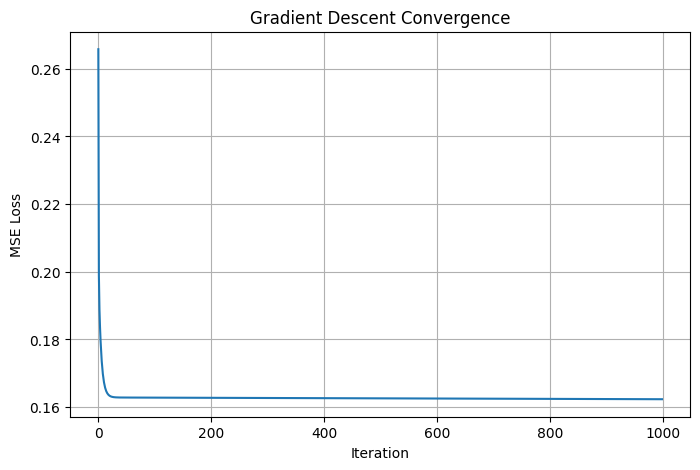

In [49]:
plt.figure(figsize=(8,5))

plt.plot(losses)

plt.xlabel("Iteration")
plt.ylabel("MSE Loss")

plt.title(
    "Gradient Descent Convergence"
)

plt.grid(True)

plt.savefig(
    "../output/figures/m2_q8_gradient_descent.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Q9. Discretize MonthlyCharges into bins (e.g., Low/High), then apply Bayes’ Theorem to compute
.𝑃(𝐶ℎ𝑢𝑟𝑛∣𝑀𝑜𝑛𝑡ℎ𝑙𝑦𝐶ℎ𝑎𝑟𝑔𝑒𝑠 𝑏𝑖𝑛)

In [42]:
df["ChargeBin"] = pd.cut(
    df["MonthlyCharges"],
    bins=2,
    labels=["Low", "High"]
)

p_churn = np.mean(df["Churn"] == "Yes")

p_high = np.mean(df["ChargeBin"] == "High")

p_high_given_churn = np.mean(df.loc[df["Churn"] == "Yes", "ChargeBin"] == "High")

bayes = (p_high_given_churn * p_churn) / p_high

print("P(Churn | High Charges):", bayes)

P(Churn | High Charges): 0.35564409030544486


Q10. Apply both L1 (Lasso) and L2 (Ridge) regularization to the Linear Regression model and compare their effects on model coefficients and performance

In [44]:
from sklearn.linear_model import Lasso, Ridge

In [46]:
lasso = Lasso(alpha=0.01)

ridge = Ridge(alpha=0.01)

lasso.fit(feature, y)

ridge.fit(feature, y)

print("Lasso")

print(lasso.coef_)

print("\nRidge")

print(ridge.coef_)

Lasso
[-0.00767721  0.00436706]

Ridge
[-0.00769847  0.00438239]


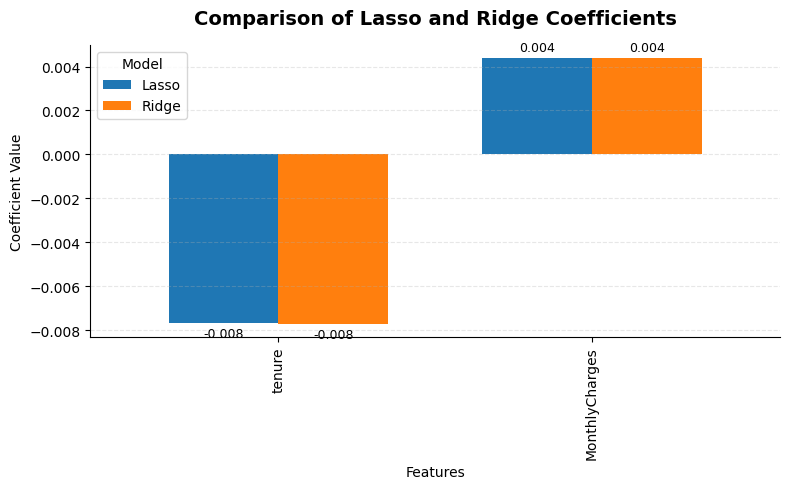

In [50]:
fig, ax = plt.subplots(figsize=(8, 5))

coef_df.plot(
    x="Feature",
    kind="bar",
    ax=ax,
    width=0.7
)

# Add value labels
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.3f",
        padding=3,
        fontsize=9
    )

ax.set_title(
    "Comparison of Lasso and Ridge Coefficients",
    fontsize=14,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Features")
ax.set_ylabel("Coefficient Value")

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

ax.legend(
    title="Model",
    frameon=True
)

# Remove unnecessary borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig(
    "../output/figures/m2_q10_lasso_ridge_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()